# 多層パーセプトロン（Multi-layer Perceptron, MLP）


In [19]:
# packageのimport
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_fontja as _matplotlib_fontja
from jaxtyping import Float

plt.style.use("bmh")
np.set_printoptions(precision=4, suppress=True)


## このノートの目的

このノートでは，次の流れでMLPの学習原理を導入する．

1. これまでの`sign`関数を`sigmoid`関数に置き換える理由を確認する．
1. `sigmoid`化した単純パーセプトロンを勾配降下法で訓練し，有用性を確認する．
1. 単層モデルではXORを学習しづらいことを確認する．
1. 多層化したMLPを勾配降下法で学習するために，backpropagationを用いる理由を解説する．


## sigmoid版単純パーセプトロン

### sign関数からsigmoid関数への変更

単純パーセプトロンで使っていた`sign`関数は，しきい値で不連続に値が切り替わる関数である．

$$
\operatorname{sign}(x)=
\begin{cases}
1 & x > 0 \
-1 & x \le 0
\end{cases}
$$

この関数はほとんどの点で微分が0になり，境界点では微分が定義しづらい．
そのため，勾配降下法でパラメータ更新する設計には向かない．

そこで本ノートでは，出力を連続値にする`sigmoid`関数を使う．

$$
\sigma(x)=
\frac{1}{1+\exp(-x)}
$$

以降では，**backpropagationでパラメータ更新を行うために，活性化関数を`sign`から`sigmoid`へ変更している**ことを前提とする．


NameError: name 'y' is not defined

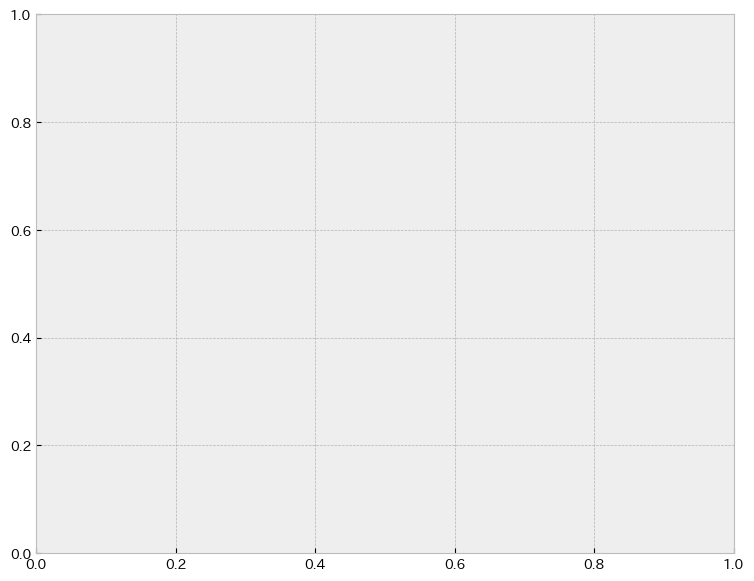

In [20]:
def sigmoid(x: Float[np.ndarray, "..."] | float) -> Float[np.ndarray, "..."] | float:
    arr = np.asarray(x, dtype=np.float64)
    # オーバーフローを避けるために入力をclipする
    arr = np.clip(arr, -50.0, 50.0)
    # ここを編集：上の式を参考にしよう．
    # 
    if np.ndim(y) == 0:
        return float(y)
    return y

x = np.linspace(-10, 10, 400)
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(x, sigmoid(x), color="tab:blue", label="sigmoid")
ax.set_title("sigmoid関数")
ax.set_xlabel("入力 x")
ax.set_ylabel("出力 sigmoid(x)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


### モデルの実装

In [ ]:
def perceptron_proba(
    X: Float[np.ndarray, "batch_size n_features"],
    W: Float[np.ndarray, "n_features"],
    b: float,
) -> Float[np.ndarray, "batch_size"]:
    logits = X @ W + b
    return sigmoid(logits)

def predict_label(
    X: Float[np.ndarray, "batch_size n_features"],
    W: Float[np.ndarray, "n_features"],
    b: float,
    threshold: float = 0.5,
) -> Float[np.ndarray, "batch_size"]:
    proba = perceptron_proba(X, W, b)
    return (proba >= threshold).astype(np.float64)


### 勾配降下法による訓練

ここでは，損失関数としてBinary Cross Entropy（BCE）を用い，その勾配を使ってパラメータを少しずつ更新する．

ここでいう **勾配（gradient）** とは，損失$L$を各パラメータで偏微分して並べた量であり，
「どの方向にどれだけパラメータを動かすと損失が増減するか」を表すベクトル（または行列）である．
例えば単純パーセプトロンでは

$$
\nabla_{W,b}L = \left(\frac{\partial L}{\partial W}, \frac{\partial L}{\partial b}\right)
$$

と表される．勾配降下法はこの勾配の逆向きへパラメータ（WeightとかBiasとか）を更新することで，損失を下げる方法である．
ここで $\nabla$ は **ナブラ（nabla）** と読み，「ある変数に関する偏微分を並べた微分演算子」を意味する記号である．$\nabla_{W,b}L$ は，$W,b$ に関する損失$L$の勾配ベクトル（または勾配の組）を表す．

パラメータ更新は次で表せる．
$$
W \leftarrow W - \eta \frac{\partial L}{\partial W},\quad
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$
ここで $\eta$ は学習率であり，1回の更新幅を調整するハイパーパラメータである．

sigmoid出力 $\hat{y}$ とBCEを組み合わせると，ロジット $z$ に関する勾配は
$$
\frac{\partial L}{\partial z} = \hat{y} - y
$$
となる．ただし，更新に直接使うのは $\frac{\partial L}{\partial W},\frac{\partial L}{\partial b}$ であり，$\frac{\partial L}{\partial z}$ はそのための中間勾配である．

$z = XW + b$ に対して微分の連鎖律を使うと
$$
\frac{\partial L}{\partial W}
= \frac{\partial L}{\partial z}\frac{\partial z}{\partial W},\quad
\frac{\partial L}{\partial b}
= \frac{\partial L}{\partial z}\frac{\partial z}{\partial b}
$$
である．ミニバッチ全体を行列で書けば，
$$
\mathrm{error} = \hat{Y} - Y \in \mathbb{R}^{n},\quad
dW = \frac{1}{n}X^\top\mathrm{error} \in \mathbb{R}^{n_{\mathrm{features}}},\quad
db = \frac{1}{n}\sum_{i=1}^{n}\mathrm{error}_i = \mathrm{mean}(\mathrm{error}) \in \mathbb{R}
$$
となる．

したがって実装の
`error = y_hat - Y`,
`dW = (X.T @ error) / n`,
`db = float(np.mean(error))`
は，この式をそのままコードに落としたものである．


In [ ]:
def binary_cross_entropy(
    y_true: Float[np.ndarray, "batch_size"],
    y_pred: Float[np.ndarray, "batch_size"],
) -> float:
    eps = 1e-7
    y_pred = np.clip(y_pred, eps, 1.0 - eps)
    return float(-np.mean(y_true * np.log(y_pred) + (1.0 - y_true) * np.log(1.0 - y_pred)))

def train_sigmoid_perceptron_gd(
    X: Float[np.ndarray, "batch_size n_features"],
    Y: Float[np.ndarray, "batch_size"],
    lr: float = 0.5,
    epochs: int = 2000,
    seed: int = 0,
) -> tuple[Float[np.ndarray, "n_features"], float, list[float]]:
    rng = np.random.default_rng(seed)
    W = rng.normal(0.0, 0.5, size=X.shape[1])
    b = float(rng.normal(0.0, 0.5))

    losses: list[float] = []
    n = X.shape[0]

    for _ in range(epochs):
        y_hat = perceptron_proba(X, W, b)
        loss = binary_cross_entropy(Y, y_hat)
        losses.append(loss)

        # BCE + sigmoid の組み合わせでは dL/dlogits = (y_hat - y) になる
        error = y_hat - Y
        dW = (X.T @ error) / n
        db = float(np.mean(error))

        W -= lr * dW
        b -= lr * db

    return W, b, losses


## 実験

### ORゲートとANDゲートを学習する


In [ ]:
truth_table = pd.DataFrame(
    {
        "x1": [0.0, 0.0, 1.0, 1.0],
        "x2": [0.0, 1.0, 0.0, 1.0],
        "or": [0.0, 1.0, 1.0, 1.0],
        "and": [0.0, 0.0, 0.0, 1.0],
        "xor": [0.0, 1.0, 1.0, 0.0],
    }
)
truth_table


,x1,x2,or,and,xor
0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,1.0,0.0,1.0
2,1.0,0.0,1.0,0.0,1.0
3,1.0,1.0,1.0,1.0,0.0


[OR] loss=0.0038, W=[10.4461 10.446 ], b=-4.7620
  正解: [0 1 1 1]
  予測: [0 1 1 1]
[AND] loss=0.0072, W=[9.1888 9.1888], b=-13.9533
  正解: [0 0 0 1]
  予測: [0 0 0 1]


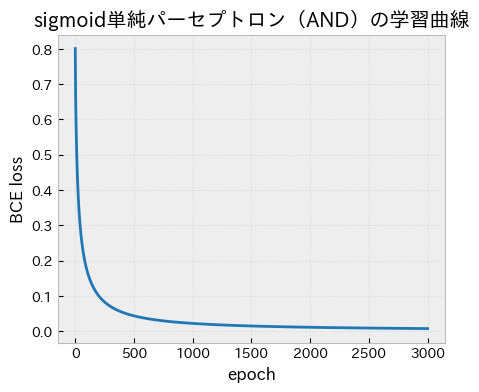

In [ ]:
X = truth_table[["x1", "x2"]].to_numpy(dtype=np.float64)

for gate in ["or", "and"]:
    Y = truth_table[gate].to_numpy(dtype=np.float64)
    W, b, losses = train_sigmoid_perceptron_gd(X, Y, lr=0.8, epochs=3000, seed=42)
    y_hat = perceptron_proba(X, W, b)
    pred = (y_hat >= 0.5).astype(int)

    print(f"[{gate.upper()}] loss={losses[-1]:.4f}, W={W}, b={b:.4f}")
    print("  正解:", Y.astype(int))
    print("  予測:", pred)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(losses, color="tab:blue")
ax.set_title("sigmoid単純パーセプトロン（AND）の学習曲線")
ax.set_xlabel("epoch")
ax.set_ylabel("BCE loss")
ax.grid(True, alpha=0.3)
plt.show()


OR/ANDのような線形分離可能な問題では，`sigmoid`化した単純パーセプトロンでも勾配降下法で安定して学習できる．
これは，`sign`を使う場合のような離散更新ではなく，連続値の損失を直接最小化できる点が有用である．


### 単層ではXORが難しい

活性関数をsigmoid，学習方法をヘブ則から勾配降下法に変えても，単純パーセプトロンではXORは解けない．

In [ ]:
Y_xor = truth_table["xor"].to_numpy(dtype=np.float64)
W_xor, b_xor, losses_xor = train_sigmoid_perceptron_gd(X, Y_xor, lr=0.8, epochs=3000, seed=42)
proba_xor = perceptron_proba(X, W_xor, b_xor)
pred_xor = (proba_xor >= 0.5).astype(int)

print(f"[XOR, 単層] loss={losses_xor[-1]:.4f}, W={W_xor}, b={b_xor:.4f}")
print("正解:", Y_xor.astype(int))
print("予測:", pred_xor)
print("確率:", np.round(proba_xor, 4))


[XOR, 単層] loss=0.6931, W=[-0. -0.], b=0.0000
正解: [0 1 1 0]
予測: [1 1 1 1]
確率: [0.5 0.5 0.5 0.5]


## 多層パーセプトロン（MLP）


<p><iframe style="border: 1px solid #ddd; border-radius: 8px;"
    src="https://playground.tensorflow.org/#activation=tanh&amp;batchSize=10&amp;dataset=circle&amp;regDataset=reg-plane&amp;learningRate=0.03&amp;regularizationRate=0&amp;noise=0&amp;networkShape=4,2&amp;seed=0.31917&amp;showTestData=false&amp;discretize=false&amp;percTrainData=50&amp;x=true&amp;y=true&amp;xTimesY=false&amp;xSquared=false&amp;ySquared=false&amp;cosX=false&amp;sinX=false&amp;cosY=false&amp;sinY=false&amp;collectStats=false&amp;problem=classification&amp;initZero=false&amp;hideText=false"
    width="100%" height="700" frameborder="0" allowfullscreen="allowfullscreen">
  </iframe></p>

### 順伝搬 （Forward Propagation）の実装

単層モデルではXORをうまく表現できないため，もう一層（隠れ層を）追加したMLPを使う．
ここでは入力2次元，隠れ層3ユニット，出力1ユニットの構成で実験する．


まずはパラメータの初期化とデータを入力してから予測値を得るまでの処理（forward propagation）の実装を行う．

In [ ]:
def init_mlp_params(seed: int = 0) -> dict[str, np.ndarray]:
    rng = np.random.default_rng(seed)
    return {
        "W1": rng.normal(0.0, 0.5, size=(2, 3)),
        "b1": np.zeros((1, 3), dtype=np.float64),
        "W2": rng.normal(0.0, 0.5, size=(3, 1)),
        "b2": np.zeros((1, 1), dtype=np.float64),
    }

def forward_mlp(
    X: Float[np.ndarray, "batch_size 2"],
    params: dict[str, np.ndarray],
) -> tuple[Float[np.ndarray, "batch_size 1"], dict[str, np.ndarray]]:
    Z1 = X @ params["W1"] + params["b1"]
    A1 = sigmoid(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    Y_hat = sigmoid(Z2)
    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "Y_hat": Y_hat}
    return Y_hat, cache

### 逆伝搬 (Back Propagation/Backward) の解説

MLPのパラメータを「タスクを解くための良い値に更新する」ために，それぞれのパラメータに対して偏微分値を求める必要がある．これを効率的に行うために，Back Propagation処理の実装をする必要がある．

MLPを
$$
z_1 = XW_1 + b_1,\quad a_1 = \sigma(z_1),\quad z_2 = a_1W_2 + b_2,\quad \hat{y} = \sigma(z_2),\quad L = \mathrm{loss}(y, \hat{y})
$$
とおく．Back Propagationでは，入力$X$ではなくパラメータ$W_1,b_1,W_2,b_2$に関する偏微分
$$
\frac{\partial L}{\partial W_2},\quad \frac{\partial L}{\partial b_2},\quad \frac{\partial L}{\partial W_1},\quad \frac{\partial L}{\partial b_1}
$$
を連鎖律で求める．具体的には次の合成関数の微分を計算している．
$$
\frac{\partial L}{\partial W_2}
= \frac{\partial L}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial z_2}\frac{\partial z_2}{\partial W_2}
$$
$$
\frac{\partial L}{\partial b_2}
= \frac{\partial L}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial z_2}\frac{\partial z_2}{\partial b_2}
$$
$$
\frac{\partial L}{\partial W_1}
= \frac{\partial L}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial z_2}\frac{\partial z_2}{\partial a_1}\frac{\partial a_1}{\partial z_1}\frac{\partial z_1}{\partial W_1}
$$
$$
\frac{\partial L}{\partial b_1}
= \frac{\partial L}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial z_2}\frac{\partial z_2}{\partial a_1}\frac{\partial a_1}{\partial z_1}\frac{\partial z_1}{\partial b_1}
$$



同じ内容を関数名を略さずに表すと，
$$
a_1 = \mathrm{sigmoid}(\mathrm{Linear}_1(X; W_1, b_1)),\\
\hat{y} = \mathrm{sigmoid}(\mathrm{Linear}_2(a_1; W_2, b_2)),\\
L = \mathrm{BCE}(y, \hat{y})
$$
であり，求めたい偏微分は
$$
\frac{\partial \mathrm{BCE}(y, \mathrm{sigmoid}(\mathrm{Linear}_2(a_1;W_2,b_2)))}{\partial W_2},\\
\frac{\partial \mathrm{BCE}(y, \mathrm{sigmoid}(\mathrm{Linear}_2(a_1;W_2,b_2)))}{\partial b_2},\\
\frac{\partial \mathrm{BCE}(y, \mathrm{sigmoid}(\mathrm{Linear}_2(a_1;W_2,b_2)))}{\partial W_1},\\
\frac{\partial \mathrm{BCE}(y, \mathrm{sigmoid}(\mathrm{Linear}_2(a_1;W_2,b_2)))}{\partial b_1}
$$
である．連鎖律で展開すると次になる．
$$
\begin{align*}
\frac{\partial L}{\partial W_2}
= &\frac{\partial \mathrm{BCE}(y, \hat{y})}{\partial \hat{y}}
\frac{\partial \mathrm{sigmoid}(\mathrm{Linear}_2(a_1;W_2,b_2))}{\partial \mathrm{Linear}_2(a_1;W_2,b_2)}
\frac{\partial \mathrm{Linear}_2(a_1;W_2,b_2)}{\partial W_2}\\

\frac{\partial L}{\partial b_2}
= &\frac{\partial \mathrm{BCE}(y, \hat{y})}{\partial \hat{y}}
\frac{\partial \mathrm{sigmoid}(\mathrm{Linear}_2(a_1;W_2,b_2))}{\partial \mathrm{Linear}_2(a_1;W_2,b_2)}
\frac{\partial \mathrm{Linear}_2(a_1;W_2,b_2)}{\partial b_2}\\

\frac{\partial L}{\partial W_1}
= &\frac{\partial \mathrm{BCE}(y, \hat{y})}{\partial \hat{y}}
\frac{\partial \mathrm{sigmoid}(\mathrm{Linear}_2(a_1;W_2,b_2))}{\partial \mathrm{Linear}_2(a_1;W_2,b_2)}\\
&\frac{\partial \mathrm{Linear}_2(a_1;W_2,b_2)}{\partial a_1}
\frac{\partial \mathrm{sigmoid}(\mathrm{Linear}_1(X;W_1,b_1))}{\partial \mathrm{Linear}_1(X;W_1,b_1)}\\
&\frac{\partial \mathrm{Linear}_1(X;W_1,b_1)}{\partial W_1}\\

\frac{\partial L}{\partial b_1}
= &\frac{\partial \mathrm{BCE}(y, \hat{y})}{\partial \hat{y}}
\frac{\partial \mathrm{sigmoid}(\mathrm{Linear}_2(a_1;W_2,b_2))}{\partial \mathrm{Linear}_2(a_1;W_2,b_2)}\\
&\frac{\partial \mathrm{Linear}_2(a_1;W_2,b_2)}{\partial a_1}
\frac{\partial \mathrm{sigmoid}(\mathrm{Linear}_1(X;W_1,b_1))}{\partial \mathrm{Linear}_1(X;W_1,b_1)}\\
&\frac{\partial \mathrm{Linear}_1(X;W_1,b_1)}{\partial b_1}
\end{align*}

$$

### 逆伝搬 (Back Propagation/Backward) の実装

In [ ]:
def backward_mlp(
    Y: Float[np.ndarray, "batch_size 1"],
    params: dict[str, np.ndarray],
    cache: dict[str, np.ndarray],
) -> dict[str, np.ndarray]:
    X, A1, Y_hat = cache["X"], cache["A1"], cache["Y_hat"]
    n = X.shape[0]

    # 出力層: BCE + sigmoid
    dZ2 = (Y_hat - Y) / n
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # 隠れ層: chain rule
    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * A1 * (1.0 - A1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

### 逆伝搬 (Back Propagation/Backward) のコードと数式の対応


`backward_mlp`関数との対応は次の通りである．

- `dZ2 = (Y_hat - Y) / n` は，BCEと出力層sigmoidを合わせた
$$
\frac{\partial L}{\partial z_2}
$$
に対応する．
- `dW2 = A1.T @ dZ2` は
$$
\frac{\partial L}{\partial W_2}
= \frac{\partial L}{\partial z_2}\frac{\partial z_2}{\partial W_2}
= \boxed{\text{dW2}}\frac{\partial z_2}{\partial W_2}
$$
に対応する．
- `db2 = np.sum(dZ2, axis=0, keepdims=True)` は
$$
\frac{\partial L}{\partial b_2}
= \frac{\partial L}{\partial z_2}\frac{\partial z_2}{\partial b_2}
= \boxed{\text{dZ2}}\frac{\partial z_2}{\partial b_2}
$$
に対応する．
- `dA1 = dZ2 @ params["W2"].T` は
$$
\frac{\partial L}{\partial a_1}
= \frac{\partial L}{\partial z_2}\frac{\partial z_2}{\partial a_1}
= \boxed{\text{dZ2}}\frac{\partial z_2}{\partial a_1}
$$
に対応する．
- `dZ1 = dA1 * A1 * (1.0 - A1)` は，隠れ層sigmoidの微分
$$
\frac{\partial L}{\partial z_1}
= \frac{\partial L}{\partial a_1}\frac{\partial a_1}{\partial z_1}
= \boxed{\text{dA1}}\frac{\partial a_1}{\partial z_1}
$$
に対応する．
- `dW1 = X.T @ dZ1` は
$$
\frac{\partial L}{\partial W_1}
= \frac{\partial L}{\partial z_1}\frac{\partial z_1}{\partial W_1}
= \boxed{\text{dZ1}}\frac{\partial z_1}{\partial W_1}
$$
に対応する．
- `db1 = np.sum(dZ1, axis=0, keepdims=True)` は
$$
\frac{\partial L}{\partial b_1}
= \frac{\partial L}{\partial z_1}\frac{\partial z_1}{\partial b_1}
= \boxed{\text{dZ1}}\frac{\partial z_1}{\partial b_1}
$$
に対応する．

```{note}
つまり，BackPropagation（誤差逆伝搬）とは，合成関数に対する連鎖律を，出力側から入力側へ逆向きに適用して，各層の勾配を効率的に計算する手法である．このとき，上流から伝わる勾配を再利用するため，同じ中間計算を繰り返さずに済む．
```

### 
ちなみにこのテクニックを使わないで計算する場合，一層目の$b_1$の勾配$\frac{\partial L}{\partial b_1}$は以下のように求めることになる．

MLPを次で定義したのだった：

$$
\begin{align*}
z_1 &= XW_1 + b_1,\\
a_1 &= \sigma(z_1),\\
z_2 &= a_1W_2 + b_2,\\
\hat{y} &= \sigma(z_2),\\
L &= \mathrm{BCE}(y,\hat{y})
\end{align*}
$$

ここで $b_1$ は最も手前の変数なので，$L$ までの全ての合成関数を通って影響が伝わる．  
したがって，連鎖律により

$$
\frac{\partial L}{\partial b_1}
=
\frac{\partial L}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial z_2}
\frac{\partial z_2}{\partial a_1}
\frac{\partial a_1}{\partial z_1}
\frac{\partial z_1}{\partial b_1}
$$

となる．

各因子の意味は次の通り．

1. $\frac{\partial L}{\partial \hat{y}}$ ：損失関数BCEの勾配  
2. $\frac{\partial \hat{y}}{\partial z_2}$ ：出力層sigmoidの勾配  
3. $\frac{\partial z_2}{\partial a_1}$ ：第2線形層の勾配  
4. $\frac{\partial a_1}{\partial z_1}$ ：隠れ層sigmoidの勾配  
5. $\frac{\partial z_1}{\partial b_1}$ ：第1線形層でのバイアス勾配

よって，$\frac{\partial L}{\partial b_1}$ を求めるには，$b_1$ 以降にある関数の勾配をすべて掛け合わせる必要がある．

実装との対応は

$$
\begin{align*}
dZ2 &= \frac{Y_{hat}-Y}{n},\\
dA1 &= dZ2 W_2^\top,\\
dZ1 &= dA1 \odot A1 \odot (1-A1),\\
db1 &= \sum_{i=1}^{n} dZ1_i
\end{align*}
$$

であり，最終的に

$$
db1 \equiv \frac{\partial L}{\partial b_1}
$$

となる．実際にはこのうちのほとんどの計算は実行済みで，キャッシュされた上流勾配をそのまま使って（再度使うことなく）局所微分と掛け算するだけなので，効率が大きく異なることがわかると思う．

最後に，forward → 損失関数計算 → backward → パラメータの更新 を任意の回数(epochs)繰り返すコードを書く．

In [ ]:
def train_mlp_xor(
    X: Float[np.ndarray, "batch_size 2"],
    Y: Float[np.ndarray, "batch_size 1"],
    lr: float = 1.2,
    epochs: int = 10000,
    seed: int = 0,
) -> tuple[dict[str, np.ndarray], list[float]]:
    params = init_mlp_params(seed=seed)
    losses: list[float] = []

    for _ in range(epochs):
        Y_hat, cache = forward_mlp(X, params)
        loss = binary_cross_entropy(Y.ravel(), Y_hat.ravel())
        losses.append(loss)

        grads = backward_mlp(Y, params, cache)
        params["W1"] -= lr * grads["dW1"]
        params["b1"] -= lr * grads["db1"]
        params["W2"] -= lr * grads["dW2"]
        params["b2"] -= lr * grads["db2"]

    return params, losses

上の関数を実行してみよう．

[XOR, MLP] loss=0.000851
正解: [0 1 1 0]
予測: [0 1 1 0]
確率: [0.001  0.9993 0.9992 0.0008]


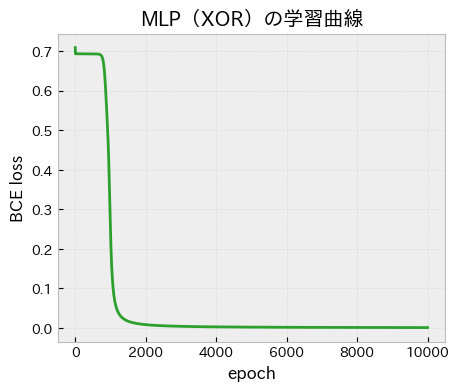

In [ ]:
X_xor = truth_table[["x1", "x2"]].to_numpy(dtype=np.float64)
Y_xor_2d = truth_table[["xor"]].to_numpy(dtype=np.float64)

params_mlp, losses_mlp = train_mlp_xor(X_xor, Y_xor_2d, lr=1.2, epochs=10000, seed=0)
proba_mlp, _ = forward_mlp(X_xor, params_mlp)
pred_mlp = (proba_mlp >= 0.5).astype(int).ravel()

print(f"[XOR, MLP] loss={losses_mlp[-1]:.6f}")
print("正解:", Y_xor_2d.ravel().astype(int))
print("予測:", pred_mlp)
print("確率:", np.round(proba_mlp.ravel(), 4))

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(losses_mlp, color="tab:green")
ax.set_title("MLP（XOR）の学習曲線")
ax.set_xlabel("epoch")
ax.set_ylabel("BCE loss")
ax.grid(True, alpha=0.3)
plt.show()


## backpropagationの役割

MLPでは，層が増えるほどパラメータ数が増えるため，勾配を手作業で展開すると計算が煩雑になる．

backpropagationは，chain ruleを使って**出力層から入力層へ順に勾配を伝播**させる方法である．
これにより，各層の勾配を再利用しながら効率よく計算できる．

実装上は，

1. forwardで中間値（`Z1`, `A1`, `Z2`, `Y_hat`）を保存し，
1. backwardで`dZ2 -> dW2/db2 -> dZ1 -> dW1/db1`の順に計算する

という流れになる．これにより，多層化したMLPも勾配降下法で学習できる．


## 参考文献

### Web
1. [Deep Learning Book - Backpropagation](https://www.deeplearningbook.org/)
1. [Stanford CS231n: Optimization and Backpropagation](https://cs231n.github.io/optimization-2/)
